## 0. Purpose

This script converts the training data to dataframes. All the classes are undersampled to the number of pixels of the smallest class. The smallest class is the "deadwood". Depending on the RUNMODE (chapter 2) the random forest is trained on just the bands (RUNMODE = BANDS); or the bands + indices + textures (RUNMODE = BANDS). Afterwards a random forest classifier is trained. Feature importance and Accuracy is displayed at the end of the script.

## 1. Import Packages


In [1]:
#%pip install xarray rioxarray pandas matplotlib rasterio
import geopandas as gpd
import xarray as xr
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import rioxarray
from rasterio import rio
from rasterio import features
from rasterio.enums import Resampling
import numpy as np
from rasterio.transform import Affine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## 2. Convert Trainingdata to dataframe

This code block builds the training dataframe.

IF RUNMODE = BANDS; only the original bands of the sent-2 data get used,
IF RUNMODE = INDEX; the orgininal bands and the indices including textures get used

### 2.1 Settings

These settings allow to quickly switche the variables and regions used train and validate the random forest. For example its now possible to train a Random forest based on all sentinel-2 scene and only use it for the scene N22 (north of bavaria, 2022). Its also possible to train a model based on S20 (south of bavaria, 2020) and use it on all the data. REGION_TRAIN_MODE is used for training, REGION_VAL_MODE for validation. If REGION_VAL_MODE and REGION_TRAIN_MODE is the same, a train/validation split of 70/30 is used. The random forest always uses a balanced (undersampled) training data set.

In [2]:
chosen_bands = [ "blue", "green", "red", "rededge1", "rededge2", "rededge3", "nir", "nir_narrow", "swir1", "swir2", "ndvi", "savi", "ndwi", "bsi", "nssi", "contrast"] #options: "blue", "green", "red", "rededge1", "rededge2", "rededge3", "nir", "nir_narrow", "swir1", "swir2", "ndvi", "savi", "ndwi", "bsi", "nssi", "contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"
REGION_TRAIN_MODE = "S20" # options: "ALL", "N22", "N23", "S20", "S22"
REGION_VAL_MODE = "N23" # options: "ALL", "N22", "N23", "S20", "S22"
BALANCE_MODE = "OVERSAMPLING" # options: "OVERSAMPLING", "UNDERSAMPLING"
OVERSAMPLE_NUMBER = 1500 # options: the number to which the deadwood class should be oversampled



### 2.2 Importing Data

This code block opens the required data, removes NAs and converts it to a pd_datframe.

In [3]:
def open_with_labels(path): # small helper function, so the band labels dont get deleted during rioxarray.open_rasterio()
    da = rioxarray.open_rasterio(path)
    if 'long_name' in da.attrs:
        da = da.assign_coords(band=list(da.attrs['long_name']))
    return da


if REGION_TRAIN_MODE == "N22":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n22.tif")
        raster = raster.drop_sel(band = "std") # not useful and NA most of the time
        df = raster.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()


if REGION_TRAIN_MODE == "N23":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n23.tif")
        raster = raster.drop_sel(band = "std")
        df = raster.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()

if REGION_TRAIN_MODE == "S20":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s20.tif")
        raster = raster.drop_sel(band = "std") # not useful and NA most of the time
        df = raster.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()


if REGION_TRAIN_MODE == "S22":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s22.tif")
        raster = raster.drop_sel(band = "std") # not useful and NA most of the time
        df = raster.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()

if REGION_TRAIN_MODE == "ALL":
        raster1 = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n22.tif")
        raster1 = raster1.drop_sel(band = "std") # not useful and NA most of the time
        raster2 = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n23.tif")
        raster2 = raster2.drop_sel(band = "std") # not useful and NA most of the time
        raster3 = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s20.tif")
        raster3 = raster3.drop_sel(band = "std") # not useful and NA most of the time
        raster4 = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s22.tif")
        raster4 = raster4.drop_sel(band = "std") # not useful and NA most of the time

        r1_flat = raster1.stack(samples=("y", "x")).dropna("samples")
        r2_flat = raster2.stack(samples=("y", "x")).dropna("samples")
        r3_flat = raster3.stack(samples=("y", "x")).dropna("samples")
        r4_flat = raster4.stack(samples=("y", "x")).dropna("samples")

        raster = xr.concat([r1_flat, r2_flat, r3_flat, r4_flat], dim='samples')
        df = raster.to_pandas().T.dropna()
        df = df.reset_index()

df.columns.name = None
df = df.loc[:, ~df.columns.duplicated()]
df["trainclass"] = (df["trainclass"] * 10000).round().astype(int)
final_selection = ["x", "y"] + [b for b in chosen_bands if b not in ["x", "y", "trainclass"]] + ["trainclass"]
df = df[final_selection]

### 2.3 Creating balanced training data

Die Kategorie 2 ("deadwood") ist vermutlich immer das nadelöhr.
The category 2 is the smallest, because areas covered in deadwood are relatively small.

In [4]:
if BALANCE_MODE == "UNDERSAMPLE":

    min_size = df["trainclass"].value_counts().min()
    print(f"Smallest class size is: {min_size}")

    balanced_list = []
    for class_id in df["trainclass"].unique():
        class_subset = df[df["trainclass"] == class_id]
        sampled_subset = class_subset.sample(n=min_size, random_state=42)
        balanced_list.append(sampled_subset)
    df = pd.concat(balanced_list).reset_index(drop=True)
    print("Value counts:\n", df["trainclass"].value_counts())

if BALANCE_MODE == "OVERSAMPLE":
# im prinzip zieh ich mir hier alle deadwood samples, mach daraus mehr und steck die dann wieder zurück in den df
    min_size = df["trainclass"].value_counts().min()
    print(f"Smallest class size is: {min_size}")

    df_dead = df[df["trainclass"] == 2]
    df_dead = df_dead.sample(len(OVERSAMPLE_NUMBER), replace=True, random_state=42)

    df = df[df['trainclass'] != 2]
    df = pd.concat([df_dead, df], axis = 0)
    print(df['trainclass'].value_counts())

## 3. Random Forest


### 3.1 Creating training and validation data

In [5]:
if REGION_TRAIN_MODE == REGION_VAL_MODE:

    preds = df.drop(columns=["trainclass", "x", "y"])
    forestclass = df["trainclass"]
    pred_train, pred_test, forestclass_train, forestclass_test = train_test_split(preds, forestclass, test_size=0.3, random_state=42)

if REGION_TRAIN_MODE != REGION_VAL_MODE:

    forestclass_train = df["trainclass"]
    pred_train = df.drop(columns=["trainclass", "x", "y"])

    if REGION_VAL_MODE == "N22":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n22.tif")

    elif REGION_VAL_MODE == "N23":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\n23.tif")

    elif REGION_VAL_MODE == "S20":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s20.tif")

    elif REGION_VAL_MODE == "S22":
        raster = open_with_labels(r"C:\Users\miles\OneDrive\Dokumente\ROOT\trainingdata_collection\trainingdata_withindices\s22.tif")

    else:
        print("PLEASE USE A VALID REGION_TRAIN_MODE")
        print("not:")
        print(REGION_VAL_MODE)

    raster = raster.drop_sel(band = "std") # not useful and NA most of the time
    df_val = raster.stack(samples=("y", "x")).to_pandas().T.dropna().reset_index()
    df_val.columns.name = None
    df_val = df_val.loc[:, ~df_val.columns.duplicated()]
    df_val["trainclass"] = (df_val["trainclass"] * 10000).round().astype(int)
    final_selection = ["x", "y"] + [b for b in chosen_bands if b not in ["x", "y", "trainclass"]] + ["trainclass"]
    df_val = df_val[final_selection]

    forestclass_test = df_val["trainclass"]
    pred_test = df_val.drop(columns=["trainclass", "x", "y"])


### 3.2 Training

In [ ]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(pred_train, forestclass_train)

### 3.3 Predicting


In [356]:
predictions = rf.predict(pred_test)

### 3.4 Accuracy Assessment


1 = clear,
2 = deadwood,
3 = undisturbed


precision = user accuracy

recall = producer accuracy

In [357]:
print(classification_report(forestclass_test, predictions))


              precision    recall  f1-score   support

           1       0.53      0.91      0.67     25745
           2       0.09      0.87      0.16      1513
           3       1.00      0.90      0.95    342186

    accuracy                           0.90    369444
   macro avg       0.54      0.90      0.59    369444
weighted avg       0.96      0.90      0.93    369444



#### 3.4.2 Confusion matrix

In [358]:
confusion_matrix = pd.crosstab(forestclass_test, predictions,
                 rownames=['Actual'],
                 colnames=['Predicted'],
                 margins=True)

print(confusion_matrix)

Predicted      1      2       3     All
Actual                                 
1          23380   2038     327   25745
2            154   1321      38    1513
3          20436  12107  309643  342186
All        43970  15466  310008  369444


### 3.4.3 Overall summary

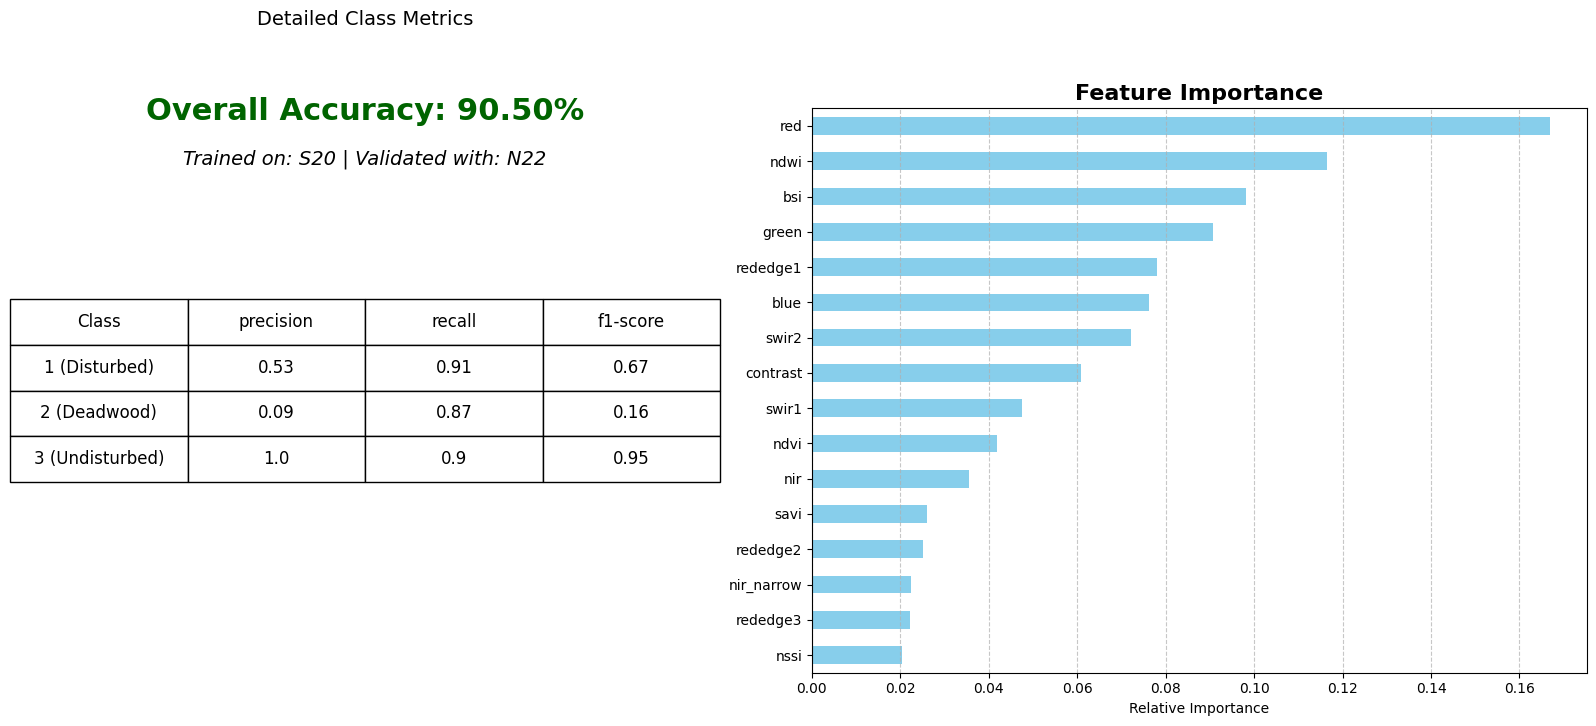

In [359]:
overall_acc = accuracy_score(forestclass_test, predictions)
report_dict = classification_report(forestclass_test, predictions, output_dict=True)

# Create the metrics table
report_df = pd.DataFrame(report_dict).iloc[:-1, :3].T
report_df.index = ['1 (Disturbed)', '2 (Deadwood)', '3 (Undisturbed)']
report_df = report_df.round(2).reset_index().rename(columns={'index': 'Class'})

# Prepare Feature Importance (using pred_train to ensure correct labels)
importances = pd.Series(rf.feature_importances_, index=pred_train.columns).sort_values(ascending=True)

# 2. Dynamic Info Line Logic
if REGION_TRAIN_MODE == REGION_VAL_MODE:
    data_info = f"Trained & Validated on: {REGION_TRAIN_MODE} (70/30 Split)"
else:
    data_info = f"Trained on: {REGION_TRAIN_MODE} | Validated with: {REGION_VAL_MODE}"

# 3. Create Combined Figure
fig, (ax_table, ax_plot) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={'width_ratios': [1, 1.2]})

# --- Left Side: Table & Accuracy Score ---
ax_table.axis('off')

# Big Overall Accuracy Score
ax_table.text(0.5, 0.98, f"Overall Accuracy: {overall_acc:.2%}",
              fontsize=22, fontweight='bold', ha='center', color='darkgreen')

# Dynamic Data Source Line
ax_table.text(0.5, 0.90, data_info,
              fontsize=14, fontstyle='italic', ha='center', color='black')

ax_table.set_title('Detailed Class Metrics', fontsize=14, pad=60)
the_table = ax_table.table(cellText=report_df.values,
                           colLabels=report_df.columns,
                           loc='center',
                           cellLoc='center')
the_table.auto_set_font_size(False)
the_table.set_fontsize(12)
the_table.scale(1.1, 3)

# --- Right Side: Bar Plot ---
importances.plot(kind='barh', color='skyblue', ax=ax_plot)
ax_plot.set_title('Feature Importance', fontsize=16, fontweight='bold')
ax_plot.set_xlabel('Relative Importance')
ax_plot.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [360]:
joblib.dump(rf, r"C:\Users\miles\OneDrive\Dokumente\ROOT\models\rf_s22_s22\rf_s22_s22.joblib")

['C:\\Users\\miles\\OneDrive\\Dokumente\\ROOT\\models\\rf_s22_s22\\rf_s22_s22.joblib']